# Metrics comparison between symbolic and numerical IK 

## Imports 

In [422]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from metrics import l2_error, rodrigues_error, combined_error

In [ ]:
test = "line"

filepath_sym = f'data/sym_{test}_data.csv'
filepath_num = f'data/qp_{test}_data.csv'

df_sym = pd.read_csv(filepath_sym, sep=",", header=0).copy()
df_num = pd.read_csv(filepath_num, sep=",", header=0).copy()

display(df_sym.head(3))
df_sym.info()
df_num.info()

,time,l_q0,l_q1,l_q2,l_q3,l_q4,l_q5,l_q6,r_q0,r_q1,r_q2,r_q3,r_q4,r_q5,r_q6,l_pose,l_real_pose,r_pose,r_real_pose
0,0.000000,2.765754,14.430173,-21.361610,-49.130623,-30.849400,30.820235,51.705157,2.765754,-14.430173,21.361610,-49.130623,30.849400,30.820235,-51.705157,"[[1.0, 0.0, 0.0, 0.2], [0.0, 1.0, 0.0, 0.33], ...","[[0.999999999999815, 6.010968602021983e-07, 9....","[[1.0, 0.0, 0.0, 0.2], [0.0, 1.0, 0.0, -0.33],...","[[0.9999999999995008, 7.706658572599685e-09, -..."
1,0.008333,3.144551,14.741613,-21.378325,-50.065157,-30.767099,30.902361,52.007010,3.144551,-14.741613,21.378325,-50.065157,30.767099,30.902361,-52.007010,"[[0.9999785816641292, -0.0, -0.006544937967351...","[[0.9999785820583464, 6.266049926778854e-07, -...","[[0.9999785816641292, -0.0, -0.006544937967351...","[[0.999978574908961, -1.1469719649497665e-08, ..."
2,0.016667,3.518658,15.041163,-21.370217,-50.981164,-30.678918,30.989767,52.279521,3.518658,-15.041163,21.370217,-50.981164,30.678918,30.989767,-52.279521,"[[0.9999143275740071, -0.0, -0.013089595571344...","[[0.9999143289007274, 6.16068206066871e-07, -0...","[[0.9999143275740071, -0.0, -0.013089595571344...","[[0.9999143145999561, 5.513983680677192e-09, -..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   time         480 non-null    float64
 1   l_q0         480 non-null    float64
 2   l_q1         480 non-null    float64
 3   l_q2         480 non-null    float64
 4   l_q3         480 non-null    float64
 5   l_q4         480 non-null    float64
 6   l_q5         480 non-null    float64
 7   l_q6         480 non-null    float64
 8   r_q0         480 non-null    float64
 9   r_q1         480 non-null    float64
 10  r_q2         480 non-null    float64
 11  r_q3         480 non-null    float64
 12  r_q4         480 non-null    float64
 13  r_q5         480 non-null    float64
 14  r_q6         480 non-null    float64
 15  l_pose       480 non-null    object 
 16  l_real_pose  480 non-null    object 
 17  r_pose       480 non-null    object 
 18  r_real_pose  480 non-null    object 
dtypes: float

In [424]:
def parse_pose_matrix(matrix_str):
    """Convert a string of a matrix into a NumPy array."""
    return np.array(ast.literal_eval(matrix_str))

In [425]:
l_pos_errs, l_rot_errs, l_comb_errs = [], [], []
r_pos_errs, r_rot_errs, r_comb_errs = [], [], []

for _, row in df_sym.iterrows():
    l_pose = parse_pose_matrix(row["l_pose"])
    l_real = parse_pose_matrix(row["l_real_pose"])

    l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
    l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])
    l_comb = combined_error(l_pos, l_rot)

    l_pos_errs.append(l_pos)
    l_rot_errs.append(l_rot)
    l_comb_errs.append(l_comb)

    r_pose = parse_pose_matrix(row["r_pose"])
    r_real = parse_pose_matrix(row["r_real_pose"])

    r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
    r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])
    r_comb = combined_error(r_pos, r_rot)

    r_pos_errs.append(r_pos)
    r_rot_errs.append(r_rot)
    r_comb_errs.append(r_comb)

df_sym["l_pos_err"] = l_pos_errs
df_sym["l_rot_err"] = l_rot_errs
df_sym["l_combined_err"] = l_comb_errs

df_sym["r_pos_err"] = r_pos_errs
df_sym["r_rot_err"] = r_rot_errs
df_sym["r_combined_err"] = r_comb_errs

display(df_sym.head(3))

,time,l_q0,l_q1,l_q2,l_q3,l_q4,l_q5,l_q6,r_q0,r_q1,...,l_pose,l_real_pose,r_pose,r_real_pose,l_pos_err,l_rot_err,l_combined_err,r_pos_err,r_rot_err,r_combined_err
0,0.000000,2.765754,14.430173,-21.361610,-49.130623,-30.849400,30.820235,51.705157,2.765754,-14.430173,...,"[[1.0, 0.0, 0.0, 0.2], [0.0, 1.0, 0.0, 0.33], ...","[[0.999999999999815, 6.010968602021983e-07, 9....","[[1.0, 0.0, 0.0, 0.2], [0.0, 1.0, 0.0, -0.33],...","[[0.9999999999995008, 7.706658572599685e-09, -...",4.564199e-07,0.000002,4.715235e-07,2.800644e-07,0.000002,2.956466e-07
1,0.008333,3.144551,14.741613,-21.378325,-50.065157,-30.767099,30.902361,52.007010,3.144551,-14.741613,...,"[[0.9999785816641292, -0.0, -0.006544937967351...","[[0.9999785820583464, 6.266049926778854e-07, -...","[[0.9999785816641292, -0.0, -0.006544937967351...","[[0.999978574908961, -1.1469719649497665e-08, ...",4.684690e-07,0.000002,4.835799e-07,2.781694e-07,0.000002,2.937654e-07
2,0.016667,3.518658,15.041163,-21.370217,-50.981164,-30.678918,30.989767,52.279521,3.518658,-15.041163,...,"[[0.9999143275740071, -0.0, -0.013089595571344...","[[0.9999143289007274, 6.16068206066871e-07, -0...","[[0.9999143275740071, -0.0, -0.013089595571344...","[[0.9999143145999561, 5.513983680677192e-09, -...",4.608224e-07,0.000002,4.759020e-07,2.678440e-07,0.000002,2.836609e-07


In [426]:
l_pos_errs, l_rot_errs, l_comb_errs = [], [], []
r_pos_errs, r_rot_errs, r_comb_errs = [], [], []

for _, row in df_num.iterrows():
    l_pose = parse_pose_matrix(row["l_pose"])
    l_real = parse_pose_matrix(row["l_real_pose"])

    l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
    l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])

    l_pos_errs.append(l_pos)
    l_rot_errs.append(l_rot)

    r_pose = parse_pose_matrix(row["r_pose"])
    r_real = parse_pose_matrix(row["r_real_pose"])

    r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
    r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])

    r_pos_errs.append(r_pos)
    r_rot_errs.append(r_rot)

df_num["l_pos_err"] = l_pos_errs
df_num["l_rot_err"] = l_rot_errs

df_num["r_pos_err"] = r_pos_errs
df_num["r_rot_err"] = r_rot_errs

display(df_num.head(3))

,time,l_q0,l_q1,l_q2,l_q3,l_q4,l_q5,l_q6,r_q0,r_q1,...,r_q5,r_q6,l_pose,l_real_pose,r_pose,r_real_pose,l_pos_err,l_rot_err,r_pos_err,r_rot_err
0,0.000000,3.458309,-2.470386,16.676819,-49.130490,-15.643256,41.78511,7.086783,3.452244,2.490591,...,41.800495,-7.053135,"[[1.0, 0.0, 0.0, 0.2], [0.0, 1.0, 0.0, 0.33], ...","[[0.9930487924155205, -0.04276468627276878, -0...","[[1.0, 0.0, 0.0, 0.2], [0.0, 1.0, 0.0, -0.33],...","[[0.9930527069134796, 0.042915116980970974, -0...",0.011585,0.122944,0.011571,0.122870
1,0.008333,3.759104,-2.557879,16.770384,-49.858305,-15.643256,41.78511,7.086783,3.756882,2.574414,...,41.800495,-7.053135,"[[0.9999785816641292, -0.0, -0.006544937967351...","[[0.9921492091903815, -0.043241656553686544, -...","[[0.9999785816641292, -0.0, -0.006544937967351...","[[0.9922535523612643, 0.043166273649806346, -0...",0.011710,0.124393,0.011630,0.123548
2,0.016667,4.088921,-2.664030,16.899153,-50.676671,-15.643256,41.78511,7.086783,4.085808,2.677693,...,41.800495,-7.053135,"[[0.9999143275740071, -0.0, -0.013089595571344...","[[0.9910014711700005, -0.04418932408137186, -0...","[[0.9999143275740071, -0.0, -0.013089595571344...","[[0.9912062278409003, 0.04400603564038173, -0....",0.011980,0.127210,0.011846,0.125685


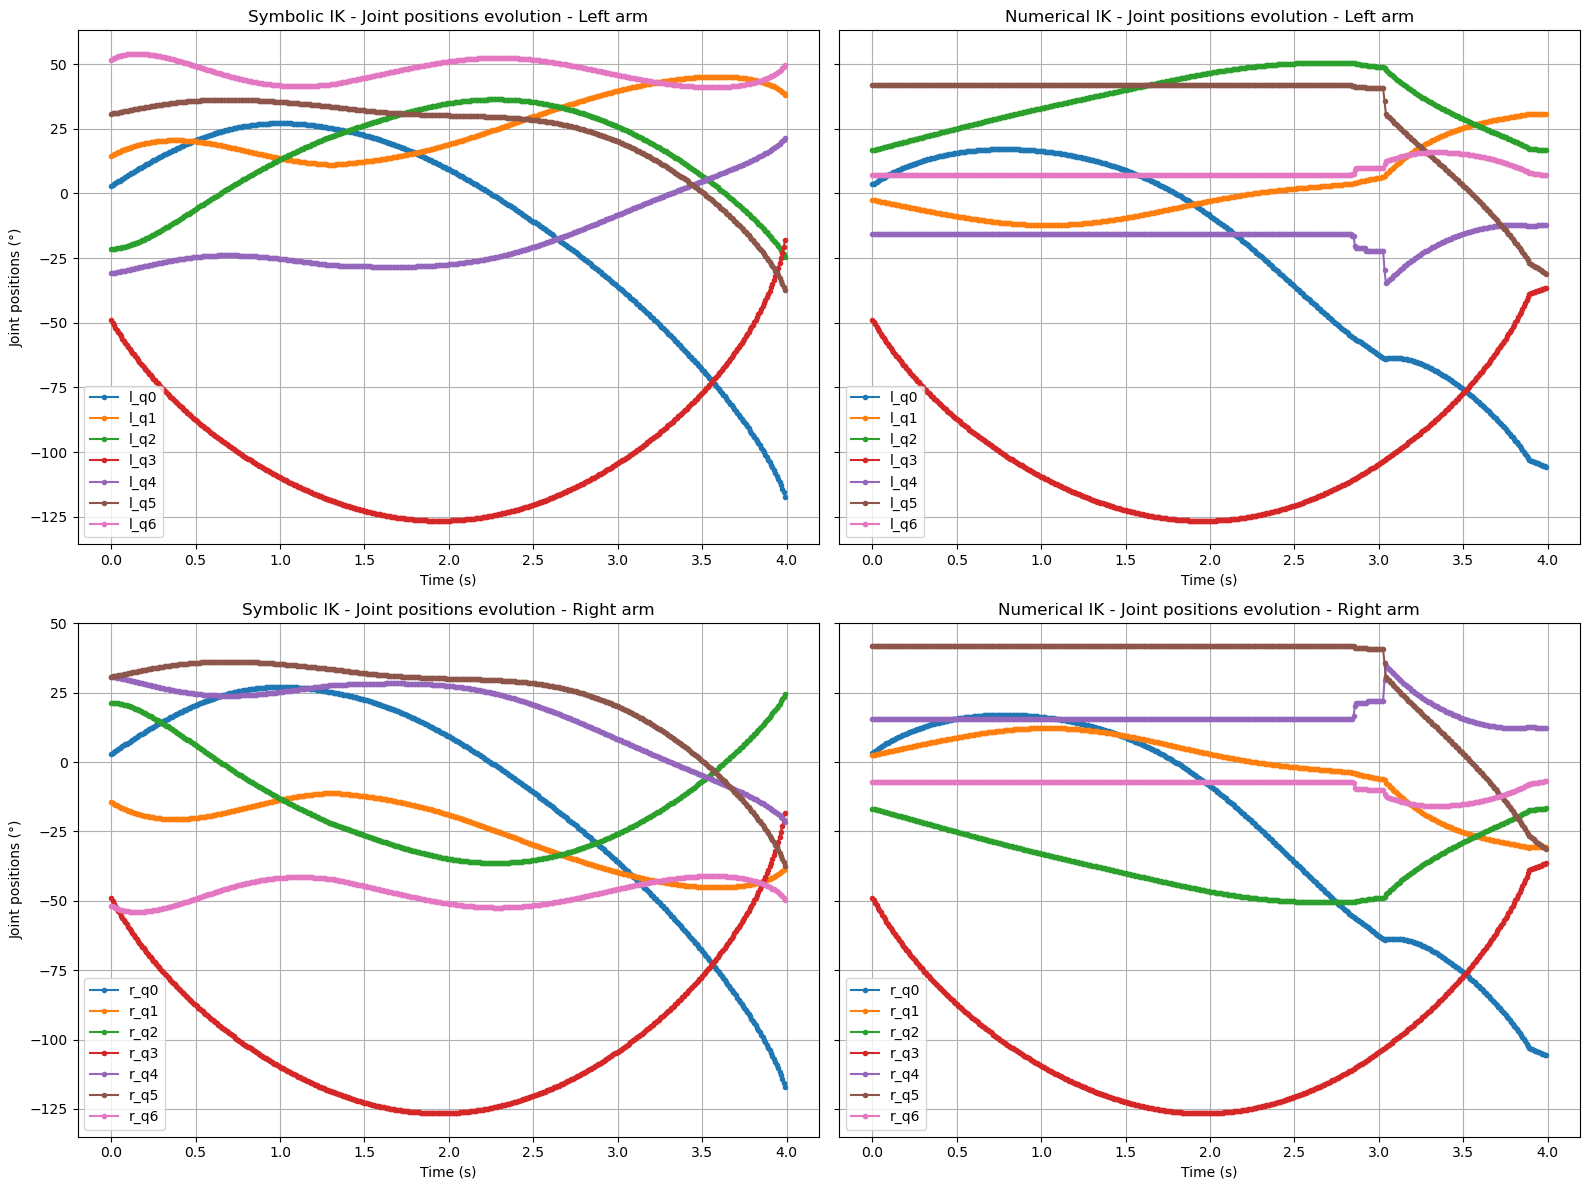

In [427]:
l_joint_cols = ["l_q0", "l_q1", "l_q2", "l_q3", "l_q4", "l_q5", "l_q6"]
r_joint_cols = ["r_q0", "r_q1", "r_q2", "r_q3", "r_q4", "r_q5", "r_q6"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey='row')

for col in l_joint_cols:
    axes[0, 0].plot(df_sym["time"], df_sym[col], label=col, marker='.')
axes[0, 0].set_title("Symbolic IK - Joint positions evolution - Left arm")
axes[0, 0].set_xlabel("Time (s)")
axes[0, 0].set_ylabel("Joint positions (°)")
axes[0, 0].legend()
axes[0, 0].grid(True)

for col in l_joint_cols:
    axes[0, 1].plot(df_num["time"], df_num[col], label=col, marker='.')
axes[0, 1].set_title("Numerical IK - Joint positions evolution - Left arm")
axes[0, 1].set_xlabel("Time (s)")
axes[0, 1].legend()
axes[0, 1].grid(True)

for col in r_joint_cols:
    axes[1, 0].plot(df_sym["time"], df_sym[col], label=col, marker='.')
axes[1, 0].set_title("Symbolic IK - Joint positions evolution - Right arm")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("Joint positions (°)")
axes[1, 0].legend()
axes[1, 0].grid(True)

for col in r_joint_cols:
    axes[1, 1].plot(df_num["time"], df_num[col], label=col, marker='.')
axes[1, 1].set_title("Numerical IK - Joint positions evolution - Right arm")
axes[1, 1].set_xlabel("Time (s)")
axes[1, 1].legend()
axes[1, 1].grid(True)


plt.tight_layout()
plt.show()

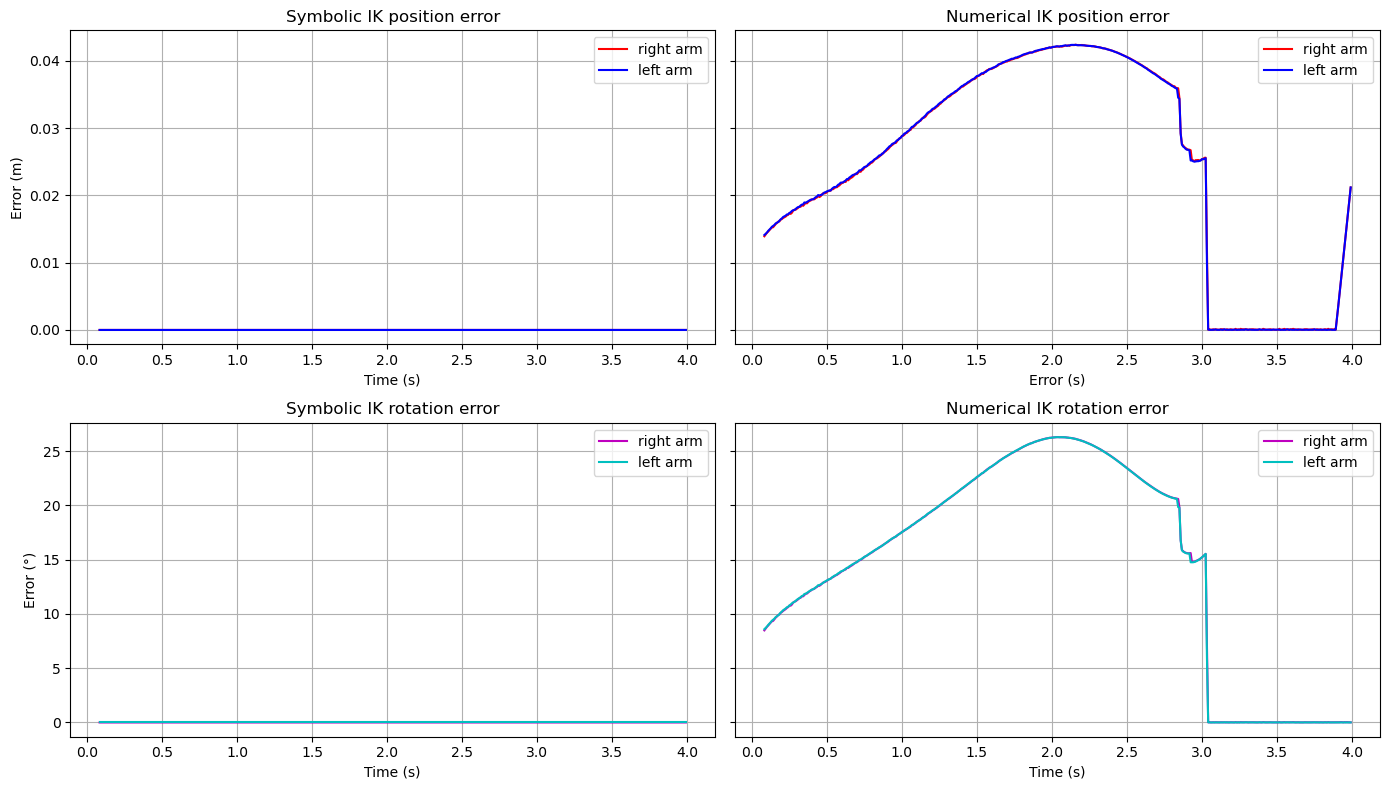

In [428]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey='row')

axes[0, 0].plot(df_sym["time"][10:], df_sym["r_pos_err"][10:], label="right arm", color="red")
axes[0, 0].plot(df_sym["time"][10:], df_sym["l_pos_err"][10:], label="left arm", color="blue")
axes[0, 0].set_title("Symbolic IK position error")
axes[0, 0].set_xlabel("Time (s)")
axes[0, 0].set_ylabel("Error (m)")
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(df_num["time"][10:], df_num["r_pos_err"][10:], label="right arm", color="red")
axes[0, 1].plot(df_num["time"][10:], df_num["l_pos_err"][10:], label="left arm", color="blue")
axes[0, 1].set_title("Numerical IK position error")
axes[0, 1].set_xlabel("Error (s)")
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(df_sym["time"][10:], np.rad2deg(df_sym["r_rot_err"][10:]), label="right arm", color="m")
axes[1, 0].plot(df_sym["time"][10:], np.rad2deg(df_sym["l_rot_err"][10:]), label="left arm", color="c")
axes[1, 0].set_title("Symbolic IK rotation error")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("Error (°)")
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(df_num["time"][10:], np.rad2deg(df_num["r_rot_err"][10:]), label="right arm", color="m")
axes[1, 1].plot(df_num["time"][10:], np.rad2deg(df_num["l_rot_err"][10:]), label="left arm", color="c")
axes[1, 1].set_title("Numerical IK rotation error")
axes[1, 1].set_xlabel("Time (s)")
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()


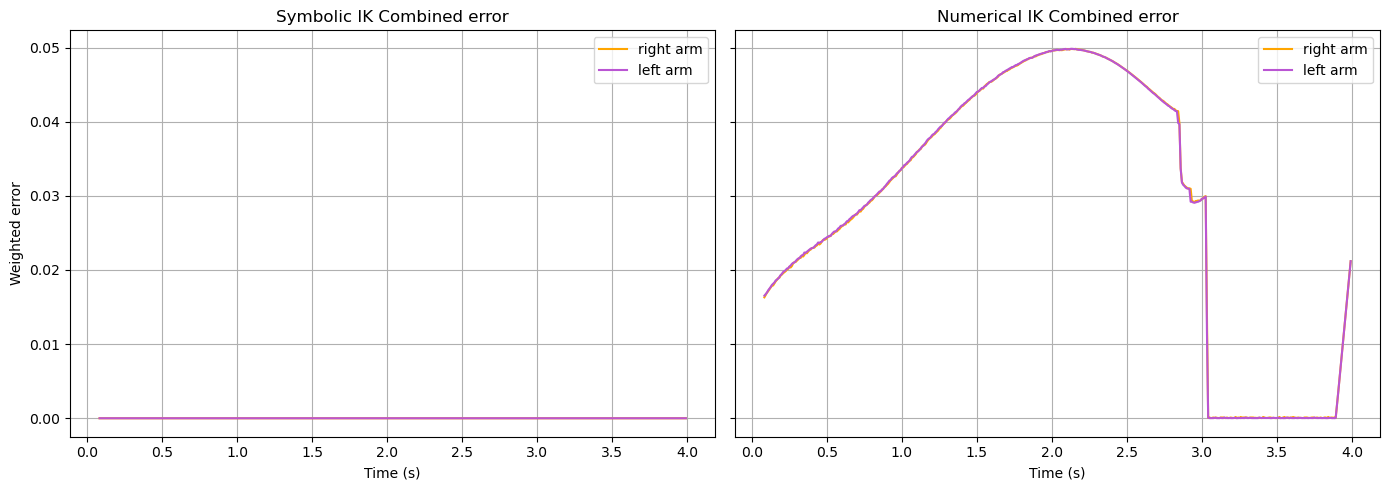

In [429]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

lambda_theta = 1e-6 / np.deg2rad(1) ** 2

axes[0].plot(df_sym["time"][10:], combined_error(df_sym["r_pos_err"], df_sym["r_rot_err"], lambda_theta=lambda_theta)[10:], label="right arm", color="orange")
axes[0].plot(df_sym["time"][10:], combined_error(df_sym["l_pos_err"], df_sym["l_rot_err"], lambda_theta=lambda_theta)[10:], label="left arm", color="mediumorchid")
axes[0].set_title("Symbolic IK Combined error")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Weighted error")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(df_num["time"][10:], combined_error(df_num["r_pos_err"], df_num["r_rot_err"], lambda_theta=lambda_theta)[10:], label="right arm", color="orange")
axes[1].plot(df_num["time"][10:], combined_error(df_num["l_pos_err"], df_num["l_rot_err"], lambda_theta=lambda_theta)[10:], label="left arm", color="mediumorchid")
axes[1].set_title("Numerical IK Combined error")
axes[1].set_xlabel("Time (s)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


## Parameters influence 

### Proportionnal corrector $K_p$

In [430]:
method = "num"

mean_l_pos_err, mean_r_pos_err = [], []
mean_l_rot_err, mean_r_rot_err = [], []

for kp in ["0010", "0025", "0050", "0075", "0100", "0125", "0150", "0175", "0200", "0300", "0400", "0500", "0600", "0750", "1000"]:
    filepath_num = f'data/{method}_circle_data_kp{kp}.csv'
    df_num = pd.read_csv(filepath_num, sep=",", header=0).copy()

    l_pos_errs, l_rot_errs, l_comb_errs = [], [], []
    r_pos_errs, r_rot_errs, r_comb_errs = [], [], []
    for _, row in df_num.iterrows():
        l_pose = parse_pose_matrix(row["l_pose"])
        l_real = parse_pose_matrix(row["l_real_pose"])

        l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
        l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])

        l_pos_errs.append(l_pos)
        l_rot_errs.append(l_rot)

        r_pose = parse_pose_matrix(row["r_pose"])
        r_real = parse_pose_matrix(row["r_real_pose"])

        r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
        r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])

        r_pos_errs.append(r_pos)
        r_rot_errs.append(r_rot)

    mean_l_pos_err.append(np.array(l_pos_errs).mean())
    mean_r_pos_err.append(np.array(r_pos_errs).mean())
    mean_l_rot_err.append(np.array(l_rot_errs).mean())
    mean_r_rot_err.append(np.array(r_rot_errs).mean())
    

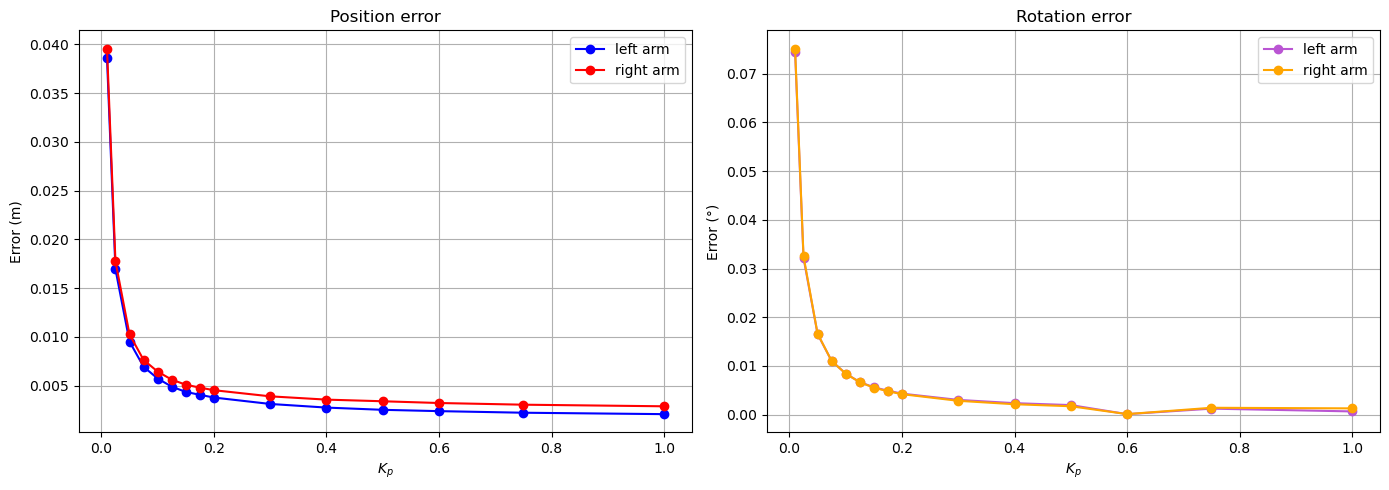

In [431]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

Kp = [0.01, 0.025, 0.050, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2, 0.3, 0.4, 0.5, 0.6, 0.75, 1.0]

axes[0].plot(Kp, mean_l_pos_err, label="left arm", color="b", marker="o")
axes[0].plot(Kp, mean_r_pos_err, label="right arm", color="r", marker="o")
axes[0].set_title("Position error")
axes[0].set_ylabel("Error (m)")
axes[0].set_xlabel("$K_p$")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(Kp, np.rad2deg(mean_l_rot_err), label="left arm", color="mediumorchid", marker="o")
axes[1].plot(Kp, np.rad2deg(mean_r_rot_err), label="right arm", color="orange", marker="o")
axes[1].set_title("Rotation error")
axes[1].set_ylabel("Error (°)")
axes[1].set_xlabel("$K_p$")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


Integration step `ik_step` 

In [432]:

mean_l_pos_err, mean_r_pos_err = [], []
mean_l_rot_err, mean_r_rot_err = [], []

for step in ["00010", "00020", "00030", "00040", "00050"]:
    filepath_num = f'data/num_circle_data_ikstep{step}.csv'
    df_num = pd.read_csv(filepath_num, sep=",", header=0).copy()

    l_pos_errs, l_rot_errs, l_comb_errs = [], [], []
    r_pos_errs, r_rot_errs, r_comb_errs = [], [], []
    for _, row in df_num.iterrows():
        l_pose = parse_pose_matrix(row["l_pose"])
        l_real = parse_pose_matrix(row["l_real_pose"])

        l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
        l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])

        l_pos_errs.append(l_pos)
        l_rot_errs.append(l_rot)

        r_pose = parse_pose_matrix(row["r_pose"])
        r_real = parse_pose_matrix(row["r_real_pose"])

        r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
        r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])

        r_pos_errs.append(r_pos)
        r_rot_errs.append(r_rot)

    mean_l_pos_err.append(np.array(l_pos_errs).mean())
    mean_r_pos_err.append(np.array(r_pos_errs).mean())
    mean_l_rot_err.append(np.array(l_rot_errs).mean())
    mean_r_rot_err.append(np.array(r_rot_errs).mean())
    

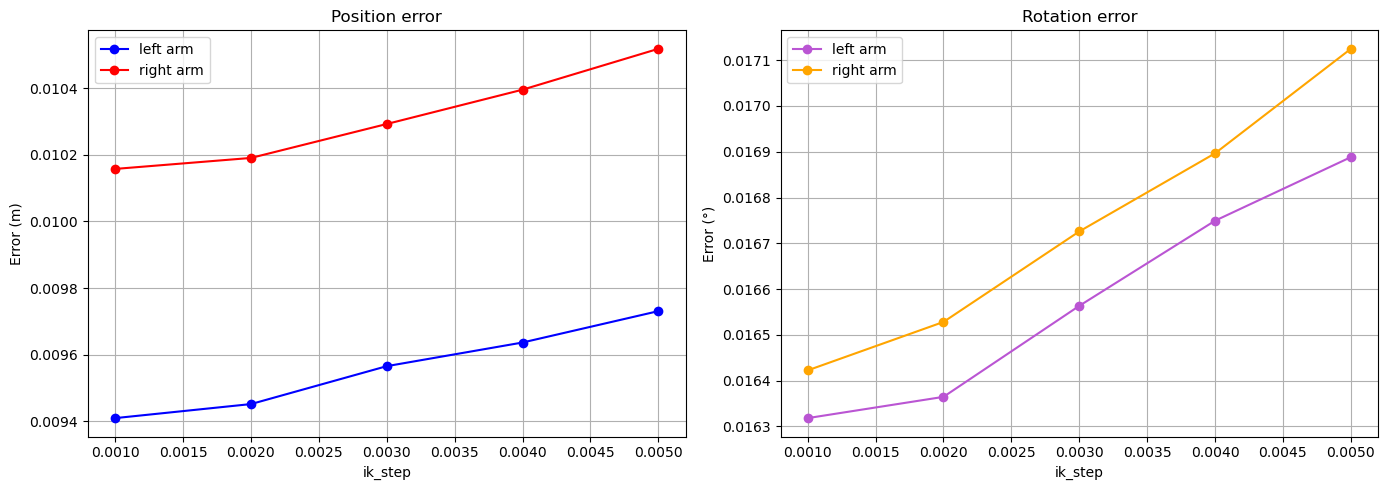

In [433]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

step = [0.001, 0.002, 0.003, 0.004, 0.005]

axes[0].plot(step, mean_l_pos_err, label="left arm", color="b", marker="o")
axes[0].plot(step, mean_r_pos_err, label="right arm", color="r", marker="o")
axes[0].set_title("Position error")
axes[0].set_ylabel("Error (m)")
axes[0].set_xlabel("ik_step")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(step, np.rad2deg(mean_l_rot_err), label="left arm", color="mediumorchid", marker="o")
axes[1].plot(step, np.rad2deg(mean_r_rot_err), label="right arm", color="orange", marker="o")
axes[1].set_title("Rotation error")
axes[1].set_ylabel("Error (°)")
axes[1].set_xlabel("ik_step")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


### Damping factor $\lambda$

In [434]:

mean_l_pos_err, mean_r_pos_err = [], []
mean_l_rot_err, mean_r_rot_err = [], []

for step in ["075e10", "075e9", "075e8", "075e7", "075e6", "075e5", "075e4", "075e3", "075e2", "075e1"]:
    filepath_num = f'data/num_circle_data_l{step}.csv'
    df_num = pd.read_csv(filepath_num, sep=",", header=0).copy()

    l_pos_errs, l_rot_errs, l_comb_errs = [], [], []
    r_pos_errs, r_rot_errs, r_comb_errs = [], [], []
    for _, row in df_num.iterrows():
        l_pose = parse_pose_matrix(row["l_pose"])
        l_real = parse_pose_matrix(row["l_real_pose"])

        l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
        l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])

        l_pos_errs.append(l_pos)
        l_rot_errs.append(l_rot)

        r_pose = parse_pose_matrix(row["r_pose"])
        r_real = parse_pose_matrix(row["r_real_pose"])

        r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
        r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])

        r_pos_errs.append(r_pos)
        r_rot_errs.append(r_rot)

    mean_l_pos_err.append(np.array(l_pos_errs).mean())
    mean_r_pos_err.append(np.array(r_pos_errs).mean())
    mean_l_rot_err.append(np.array(l_rot_errs).mean())
    mean_r_rot_err.append(np.array(r_rot_errs).mean())
    

<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_6062/1896034454.py:9: SyntaxWarning: invalid escape sequence '\l'
  axes[0].set_xlabel("$\log(\lambda)$")
/tmp/ipykernel_6062/1896034454.py:18: SyntaxWarning: invalid escape sequence '\l'
  axes[1].set_xlabel("$\log(\lambda)$")


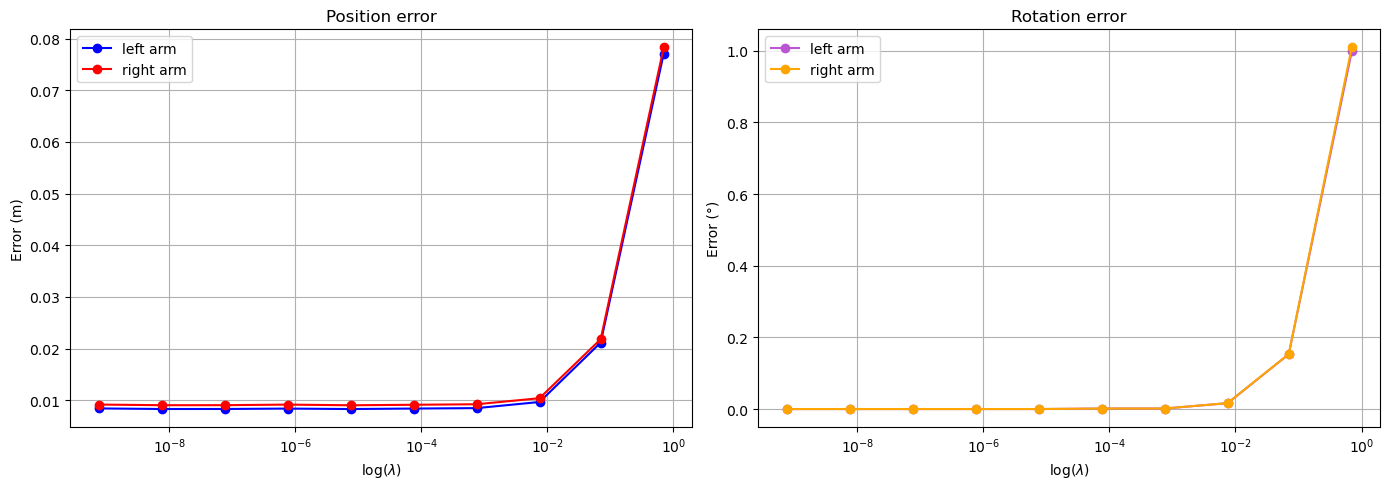

In [435]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

_lambda = [7.5e-10, 7.5e-9, 7.5e-8, 7.5e-7, 7.5e-6, 7.5e-5, 7.5e-4, 7.5e-3, 7e-2, 7e-1]

axes[0].plot(_lambda, mean_l_pos_err, label="left arm", color="b", marker="o")
axes[0].plot(_lambda, mean_r_pos_err, label="right arm", color="r", marker="o")
axes[0].set_title("Position error")
axes[0].set_ylabel("Error (m)")
axes[0].set_xlabel("$\log(\lambda)$")
axes[0].set_xscale('log')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(_lambda, np.rad2deg(mean_l_rot_err), label="left arm", color="mediumorchid", marker="o")
axes[1].plot(_lambda, np.rad2deg(mean_r_rot_err), label="right arm", color="orange", marker="o")
axes[1].set_title("Rotation error")
axes[1].set_ylabel("Error (°)")
axes[1].set_xlabel("$\log(\lambda)$")
axes[1].set_xscale('log')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
